In [1]:
import numpy as np,pandas as pd,seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\SUBRATA\Downloads\BlinkIT Grocery Data.csv")

In [3]:
df

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


In [4]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [6]:
null_data=(df.isnull().sum()/len(df))*100
print(null_data)

Item Fat Content              0.000000
Item Identifier               0.000000
Item Type                     0.000000
Outlet Establishment Year     0.000000
Outlet Identifier             0.000000
Outlet Location Type          0.000000
Outlet Size                   0.000000
Outlet Type                   0.000000
Item Visibility               0.000000
Item Weight                  17.165317
Sales                         0.000000
Rating                        0.000000
dtype: float64


In [12]:
print(df["Item Fat Content"].unique())

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str


In [13]:
df["Item Fat Content"]=df["Item Fat Content"].replace({"low fat":"Low Fat","LF":"Low Fat","reg":"Regular"})

In [14]:
df["Item Weight"]=df["Item Weight"].fillna(df["Item Weight"]).median

In [21]:
#Total Sales
total_sales=df["Sales"].sum()
#Avg sales
avg_sales=df["Sales"].mean()
#No of Item Sold
item_sold=df["Sales"].count()
#Avg Rating
avg_rating=df["Rating"].mean()

print(f"total sales:{total_sales:,.0f}")
print(f"avg_sales:{avg_sales:,.0f}")
print(f"item_sold:{item_sold:,.0f}")
print(f"avg_rating:{avg_rating:,.0f}")

total sales:1,201,681
avg_sales:141
item_sold:8,523
avg_rating:4


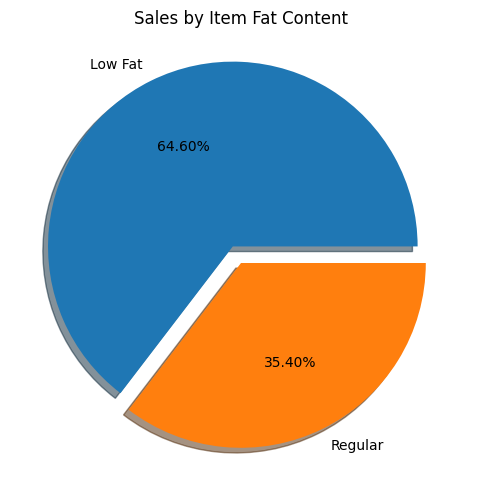

In [31]:
sales = df.groupby("Item Fat Content")["Sales"].sum()

plt.figure(figsize=(6,6))
plt.pie(sales, labels=sales.index, autopct="%1.2f%%", shadow=True,explode=[0.1,0])
plt.title("Sales by Item Fat Content")
plt.show()

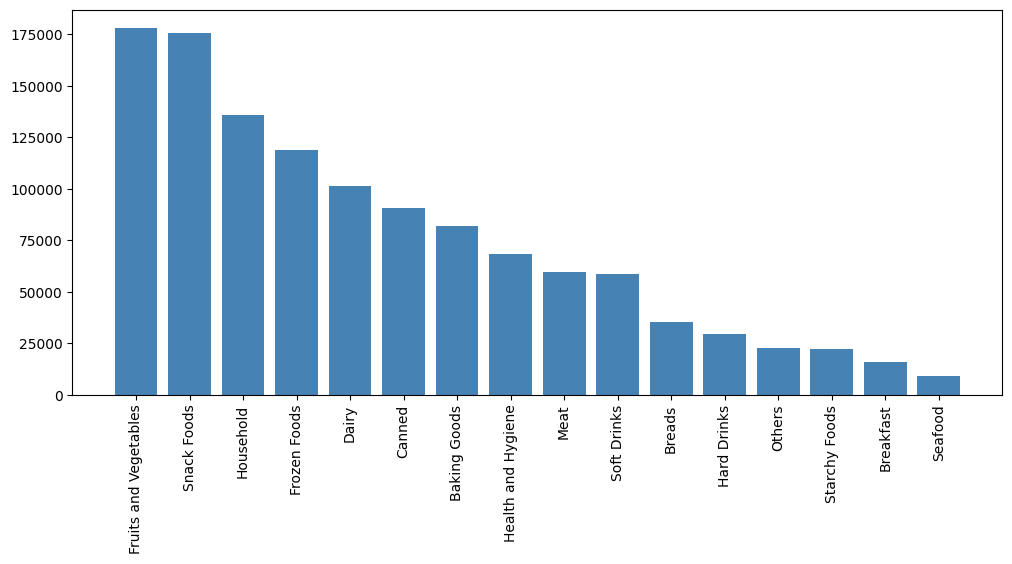

In [41]:
sales1=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(12,5))
plt.bar(sales1.index, sales1.values, color="steelblue")
plt.xticks(rotation=90)
plt.show()

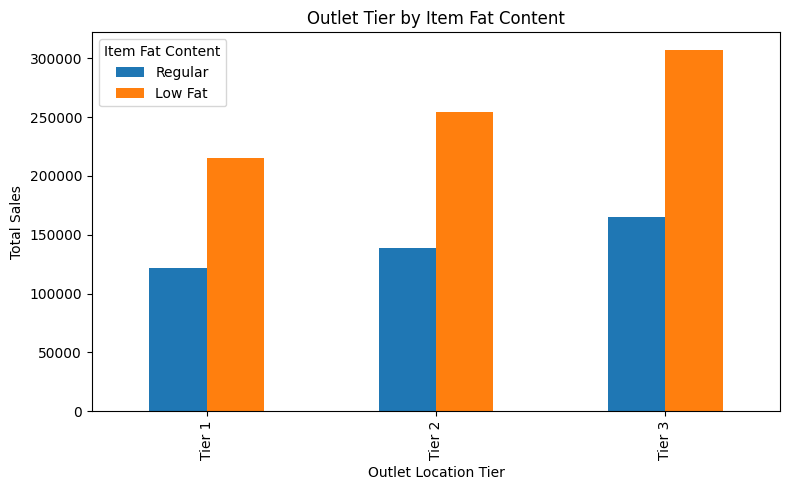

In [48]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]
ax = grouped.plot(kind='bar', figsize=(8, 5), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()

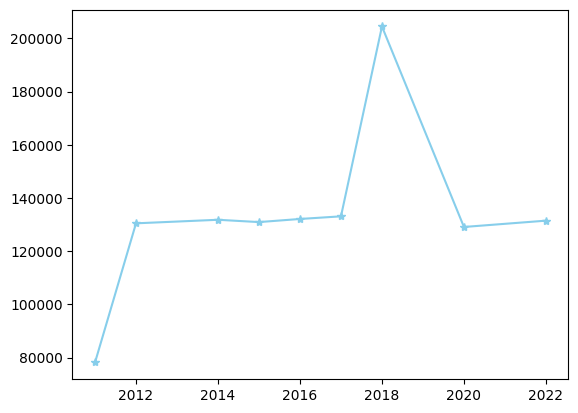

In [58]:
sales_year=df.groupby("Outlet Establishment Year")["Sales"].sum()
plt.plot(sales_year.index,sales_year.values,marker="*",linestyle="-",color="skyblue")

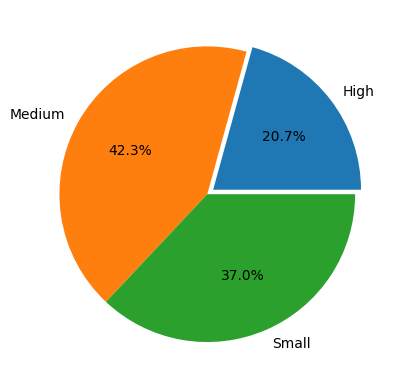

In [68]:
size_by_sales=df.groupby("Outlet Size")["Sales"].sum()
plt.pie(size_by_sales,labels=size_by_sales.index,autopct="%1.1f%%",explode=[.05,0,0])
plt.show()

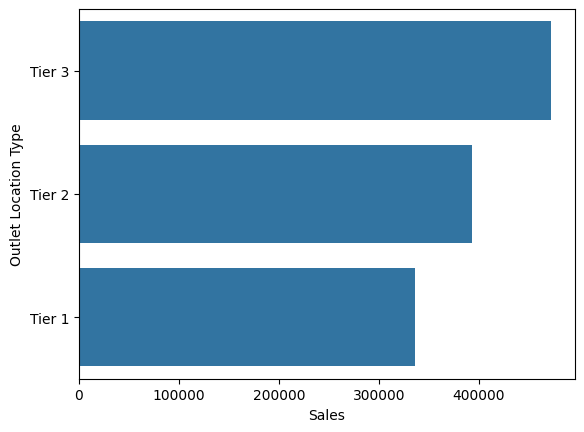

In [76]:
sales_location=df.groupby("Outlet Location Type")["Sales"].sum()
sales_location=sales_location.sort_values(ascending=False)
sales_df = sales_location.reset_index()
ax=sns.barplot(x="Sales",y="Outlet Location Type",data=sales_df)